In [1]:
!pip install pandas numpy scikit-learn tensorflow gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.8 MB/s eta 0:00:00


In [24]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.utils.validation import check_is_fitted
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
import gradio as gr


drive.mount('/content/drive', force_remount=True)
os.makedirs('/content/drive/MyDrive/Churn_Models_Separate', exist_ok=True)

Mounted at /content/drive


In [25]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
data = data.drop('customerID', axis=1)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

In [26]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
label_encoder = LabelEncoder()
for col in binary_cols:
    data[col] = label_encoder.fit_transform(data[col])

# Encode categorical columns
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [27]:
X = data.drop('Churn', axis=1)
y = data['Churn']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [28]:
feature_names = X.columns.tolist()
with open('/content/drive/MyDrive/Churn_Models_Separate/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

In [29]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_numerical = scaler.fit_transform(X_train[numerical_cols])
X_val_numerical = scaler.transform(X_val[numerical_cols])
X_test_numerical = scaler.transform(X_test[numerical_cols])

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()
X_train[numerical_cols] = X_train_numerical
X_val[numerical_cols] = X_val_numerical
X_test[numerical_cols] = X_test_numerical

In [30]:
with open('/content/drive/MyDrive/Churn_Models_Separate/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [31]:
from tensorflow.keras.layers import Input

def create_FNN_model(optimizer='Adam'):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer.lower(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [32]:
optimizers = ['Adam', 'RMSprop', 'SGD']
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
test_results = {}
model_type = 'FNN'
test_results_path = '/content/drive/MyDrive/Churn_Models_Separate/test_results_FNN.pkl'
history_data = {}

for optimizer in optimizers:
    model = create_FNN_model(optimizer)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32,
                        callbacks=[early_stopping], verbose=0)
    history_data[f'FNN_{optimizer}'] = {
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
        'accuracy': history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy']
    }
    model.save(f'/content/drive/MyDrive/Churn_Models_Separate/FNN_{optimizer}.keras')

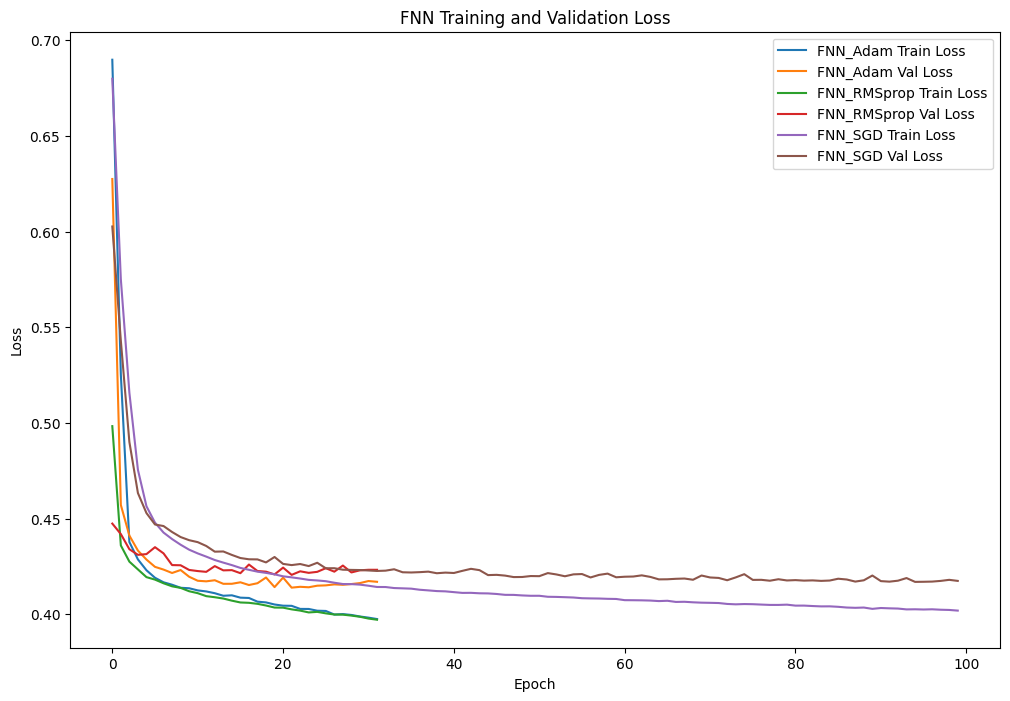

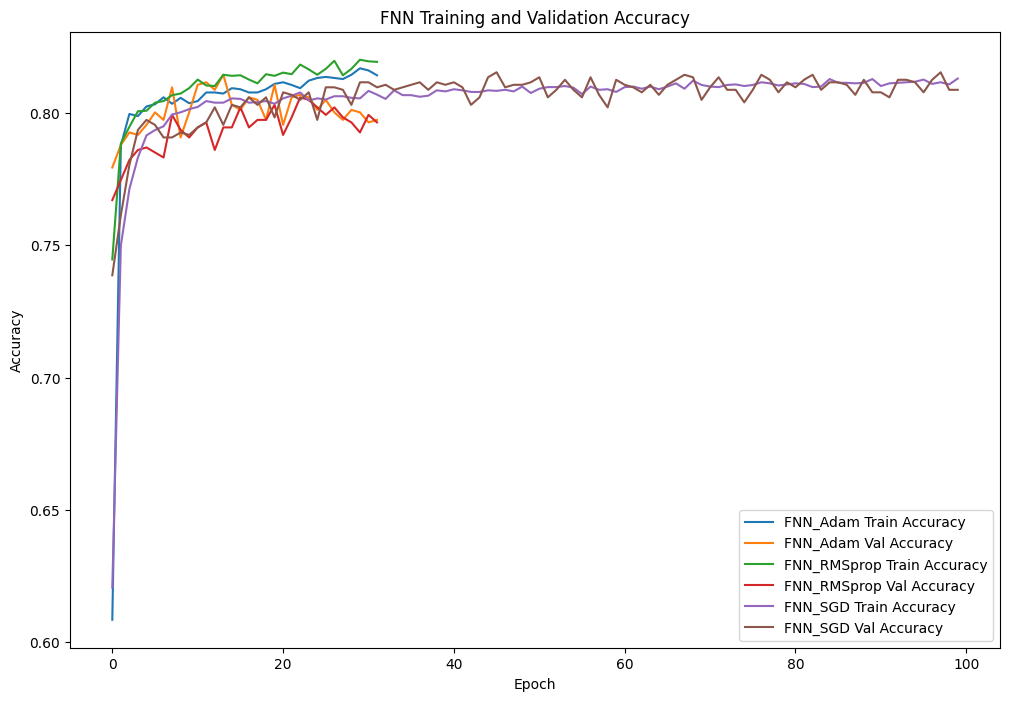

In [33]:
# Plot training and validation loss
plt.figure(figsize=(12, 8))
for model_opt, history in history_data.items():
    plt.plot(history['loss'], label=f'{model_opt} Train Loss')
    plt.plot(history['val_loss'], label=f'{model_opt} Val Loss')
plt.title('FNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/Churn_Models_Separate/FNN_loss_plot.png')
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(12, 8))
for model_opt, history in history_data.items():
    plt.plot(history['accuracy'], label=f'{model_opt} Train Accuracy')
    plt.plot(history['val_accuracy'], label=f'{model_opt} Val Accuracy')
plt.title('FNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/Churn_Models_Separate/FNN_accuracy_plot.png')
plt.show()

In [34]:
def compute_test_results():
    for optimizer in optimizers:
        try:
            model = load_model(f'/content/drive/MyDrive/Churn_Models_Separate/FNN_{optimizer}.keras')
            y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)
            test_results[f'FNN_{optimizer}'] = {
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, zero_division=0),
                'recall': recall_score(y_test, y_pred, zero_division=0),
                'f1': f1_score(y_test, y_pred, zero_division=0)
            }
            print(f"Metrics for FNN_{optimizer}: {test_results[f'FNN_{optimizer}']}")  # Debug print
        except Exception as e:
            print(f"Error computing metrics for FNN_{optimizer}: {str(e)}")
            test_results[f'FNN_{optimizer}'] = {
                'accuracy': 'N/A',
                'precision': 'N/A',
                'recall': 'N/A',
                'f1': 'N/A'
            }
    try:
        with open(test_results_path, 'wb') as f:
            pickle.dump(test_results, f)
    except Exception as e:
        print(f"Error saving test_results: {str(e)}")

try:
    compute_test_results()
except NameError as e:
    raise NameError("X_test or y_test not defined. Please re-run preprocessing.")

Metrics for FNN_Adam: {'accuracy': 0.8032166508987701, 'precision': 0.6780487804878049, 'recall': 0.49466192170818507, 'f1': 0.5720164609053497}
Metrics for FNN_RMSprop: {'accuracy': 0.7956480605487228, 'precision': 0.6756756756756757, 'recall': 0.44483985765124556, 'f1': 0.5364806866952789}
Metrics for FNN_SGD: {'accuracy': 0.7975402081362346, 'precision': 0.6666666666666666, 'recall': 0.47686832740213525, 'f1': 0.5560165975103735}


In [35]:
class KerasClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, model_path):
        self.model_path = model_path
        self.model = load_model(model_path)
        if self.model.output_shape != (None, 1):
            raise ValueError(f"Expected model output shape (None, 1), got {self.model.output_shape}")
        last_layer = self.model.layers[-1]
        if not hasattr(last_layer, 'activation') or last_layer.activation.__name__ != 'sigmoid':
            print(f"Warning: Last layer activation is {last_layer.activation.__name__}, expected sigmoid")
        self.classes_ = np.array([0, 1])
        self._estimator_type = "classifier"
        self._is_classifier = True
        self.is_fitted_ = False

    def fit(self, X, y):
        if X.shape[1] != 30:
            raise ValueError(f"Expected 30 features, got {X.shape[1]}")
        if not np.all(np.isin(np.unique(y), [0, 1])):
            raise ValueError("Expected binary labels (0, 1)")
        self.is_fitted_ = True
        self.n_features_in_ = X.shape[1]
        self.classes_ = np.array([0, 1])
        self.n_classes_ = len(self.classes_)
        return self

    def predict_proba(self, X):
        check_is_fitted(self, ['is_fitted_', 'n_features_in_', 'classes_', 'n_classes_'])
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Expected {self.n_features_in_} features, got {X.shape[1]}")
        probs = self.model.predict(X, verbose=0)
        if probs.ndim == 1:
            probs = probs.reshape(-1, 1)
        probs = np.clip(probs, 1e-10, 1 - 1e-10)
        result = np.hstack([1 - probs, probs])
        result = result / np.sum(result, axis=1, keepdims=True)
        return result

    def predict(self, X):
        check_is_fitted(self, ['is_fitted_', 'n_features_in_', 'classes_', 'n_classes_'])
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Expected {self.n_features_in_} features, got {X.shape[1]}")
        probs = self.model.predict(X, verbose=0)
        return (probs > 0.5).astype(int).flatten()

    def decision_function(self, X):
        check_is_fitted(self, ['is_fitted_', 'n_features_in_', 'classes_', 'n_classes_'])
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Expected {self.n_features_in_} features, got {X.shape[1]}")
        probs = self.model.predict(X, verbose=0)
        if probs.ndim == 1:
            probs = probs.reshape(-1, 1)
        probs = np.clip(probs, 1e-10, 1 - 1e-10)
        decision = np.log(probs / (1 - probs))
        return decision.flatten()

In [37]:
def map_inputs_to_features(
    tenure, MonthlyCharges, TotalCharges, gender, SeniorCitizen, Partner, Dependents, PhoneService,
    MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection,
    TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod
):
    input_dict = {f: 0 for f in feature_names}
    input_dict['tenure'] = float(tenure)
    input_dict['MonthlyCharges'] = float(MonthlyCharges)
    input_dict['TotalCharges'] = float(TotalCharges)
    input_dict['gender'] = 1 if gender == 'Male' else 0
    input_dict['SeniorCitizen'] = 1 if SeniorCitizen == 'Yes' else 0
    input_dict['Partner'] = 1 if Partner == 'Yes' else 0
    input_dict['Dependents'] = 1 if Dependents == 'Yes' else 0
    input_dict['PhoneService'] = 1 if PhoneService == 'Yes' else 0
    input_dict['PaperlessBilling'] = 1 if PaperlessBilling == 'Yes' else 0
    input_dict['MultipleLines_No phone service'] = 1 if MultipleLines == 'No phone service' else 0
    input_dict['MultipleLines_Yes'] = 1 if MultipleLines == 'Yes' else 0
    input_dict['InternetService_Fiber optic'] = 1 if InternetService == 'Fiber optic' else 0
    input_dict['InternetService_No'] = 1 if InternetService == 'No' else 0
    input_dict['OnlineSecurity_No internet service'] = 1 if OnlineSecurity == 'No internet service' else 0
    input_dict['OnlineSecurity_Yes'] = 1 if OnlineSecurity == 'Yes' else 0
    input_dict['OnlineBackup_No internet service'] = 1 if OnlineBackup == 'No internet service' else 0
    input_dict['OnlineBackup_Yes'] = 1 if OnlineBackup == 'Yes' else 0
    input_dict['DeviceProtection_No internet service'] = 1 if DeviceProtection == 'No internet service' else 0
    input_dict['DeviceProtection_Yes'] = 1 if DeviceProtection == 'Yes' else 0
    input_dict['TechSupport_No internet service'] = 1 if TechSupport == 'No internet service' else 0
    input_dict['TechSupport_Yes'] = 1 if TechSupport == 'Yes' else 0
    input_dict['StreamingTV_No internet service'] = 1 if StreamingTV == 'No internet service' else 0
    input_dict['StreamingTV_Yes'] = 1 if StreamingTV == 'Yes' else 0
    input_dict['StreamingMovies_No internet service'] = 1 if StreamingMovies == 'No internet service' else 0
    input_dict['StreamingMovies_Yes'] = 1 if StreamingMovies == 'Yes' else 0
    input_dict['Contract_One year'] = 1 if Contract == 'One year' else 0
    input_dict['Contract_Two year'] = 1 if Contract == 'Two year' else 0
    input_dict['PaymentMethod_Credit card (automatic)'] = 1 if PaymentMethod == 'Credit card (automatic)' else 0
    input_dict['PaymentMethod_Electronic check'] = 1 if PaymentMethod == 'Electronic check' else 0
    input_dict['PaymentMethod_Mailed check'] = 1 if PaymentMethod == 'Mailed check' else 0
    input_df = pd.DataFrame([input_dict], columns=feature_names)
    if input_df.shape[1] != 30:
        raise ValueError(f"Input DataFrame has {input_df.shape[1]} columns, expected 30")
    input_array = input_df.values
    numerical_data = input_df[numerical_cols].values
    scaled_numerical = scaler.transform(input_df[numerical_cols])
    numerical_indices = [feature_names.index(col) for col in numerical_cols]
    input_array[:, numerical_indices] = scaled_numerical
    if input_array.shape[1] != 30:
        raise ValueError(f"Final input array has {input_array.shape[1]} features, expected 30")
    return input_array

def predict_churn(
    optimizer,
    tenure, MonthlyCharges, TotalCharges, gender, SeniorCitizen, Partner, Dependents, PhoneService,
    MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection,
    TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod
):
    try:
        model_path = f"/content/drive/MyDrive/Churn_Models_Separate/FNN_{optimizer}.keras"
        if not os.path.exists(model_path):
            return f"Model file not found: {model_path}. Please ensure the training cell has been run."
        keras_model = KerasClassifier(model_path)
        keras_model.fit(X_val, y_val)
        check_is_fitted(keras_model, ['is_fitted_', 'n_features_in_', 'classes_', 'n_classes_'])
        raw_probs = keras_model.predict_proba(X_val)[:, 1].reshape(-1, 1)
        if raw_probs.shape[1] != 1:
            raise ValueError(f"Expected raw_probs to have 1 feature, got {raw_probs.shape[1]}")
        calibrator = LogisticRegression()
        calibrator.fit(raw_probs, y_val)
        val_probs = calibrator.predict_proba(raw_probs)[:, 1]
        input_array = map_inputs_to_features(
            tenure, MonthlyCharges, TotalCharges, gender, SeniorCitizen, Partner, Dependents, PhoneService,
            MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection,
            TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod
        )
        raw_prob = keras_model.predict_proba(input_array)[:, 1].reshape(-1, 1)
        if raw_prob.shape[1] != 1:
            raise ValueError(f"Expected raw_prob to have 1 feature, got {raw_prob.shape[1]}")
        prob = calibrator.predict_proba(raw_prob)[0][1]
        churn = "Churn" if prob > 0.5 else "No Churn"
        metrics = test_results.get(f"FNN_{optimizer}", {})
        print(f"Raw metrics for FNN_{optimizer}: {metrics}")  # Debug print
        metrics_lines = []
        for metric in ['accuracy', 'precision', 'recall', 'f1']:
            value = metrics.get(metric, 'N/A')
            if isinstance(value, (int, float)):
                metrics_lines.append(f"{metric.capitalize()}: {value:.4f}")
            else:
                metrics_lines.append(f"{metric.capitalize()}: {value}")
        metrics_str = "\n".join(metrics_lines)
        return (f"Prediction: {churn}\n"
                f"Confidence: {prob:.4f}\n\n"
                f"Test Metrics:\n{metrics_str}")
    except Exception as e:
        return f"Error: {str(e)}"

In [ ]:
with gr.Blocks() as demo:
    gr.Markdown("# Telco Customer Churn Prediction - FNN Model")
    optimizer_choice = gr.Dropdown(choices=['Adam', 'RMSprop', 'SGD'], label="Select Optimizer")
    gr.Markdown("### Customer Data")
    with gr.Row():
        tenure = gr.Slider(0, 72, label="Tenure (months)", step=1)
        MonthlyCharges = gr.Slider(0, 200, label="Monthly Charges ($)", step=0.1)
        TotalCharges = gr.Slider(0, 10000, label="Total Charges ($)", step=1)
    with gr.Row():
        gender = gr.Dropdown(choices=['Male', 'Female'], label="Gender")
        SeniorCitizen = gr.Dropdown(choices=['Yes', 'No'], label="Senior Citizen")
        Partner = gr.Dropdown(choices=['Yes', 'No'], label="Partner")
        Dependents = gr.Dropdown(choices=['Yes', 'No'], label="Dependents")
        PhoneService = gr.Dropdown(choices=['Yes', 'No'], label="Phone Service")
    with gr.Row():
        PaperlessBilling = gr.Dropdown(choices=['Yes', 'No'], label="Paperless Billing")
        MultipleLines = gr.Dropdown(choices=['No', 'Yes', 'No phone service'], label="Multiple Lines")
        InternetService = gr.Dropdown(choices=['DSL', 'Fiber optic', 'No'], label="Internet Service")
        Contract = gr.Dropdown(choices=['Month-to-month', 'One year', 'Two year'], label="Contract")
    with gr.Row():
        PaymentMethod = gr.Dropdown(choices=['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check'], label="Payment Method")
        OnlineSecurity = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Online Security")
        OnlineBackup = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Online Backup")
        DeviceProtection = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Device Protection")
    with gr.Row():
        TechSupport = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Tech Support")
        StreamingTV = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Streaming TV")
        StreamingMovies = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Streaming Movies")
    predict_button = gr.Button("Predict")
    output = gr.Textbox(label="Prediction and Metrics", lines=10)
    predict_button.click(
        fn=predict_churn,
        inputs=[
            optimizer_choice,
            tenure, MonthlyCharges, TotalCharges, gender, SeniorCitizen, Partner, Dependents, PhoneService,
            MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection,
            TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod
        ],
        outputs=output
    )

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://475c7f8b037948d927.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Raw metrics for FNN_Adam: {'accuracy': 0.8032166508987701, 'precision': 0.6780487804878049, 'recall': 0.49466192170818507, 'f1': 0.5720164609053497}
